# Decision Trees and Random Forests

In [1]:
import numpy as np
import pandas as pd
from IPython.display import Image
import matplotlib.pyplot as plt
import chart_studio.plotly as py
import plotly.graph_objs as go 
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import tree
from io import StringIO  # Updated import statement
import pydotplus
from sklearn.ensemble import RandomForestClassifier


### Downloading, cleaning and shaping
We start by downloading the data and choosing the variables. There are many reasons why only about half of the available variables are chosen. For example, <br>
- The variables may have been strings, like name of the city or the perpetrator group name (70+ entries) making them difficult to categorize.<br>
- There were too many missing values for a variable and replacing them artificially might have distorted the results, so they were left out. For example, *'number of perpetrators'*; too many were unknown.


In [2]:
input_file = "globalterrorismdb.csv"

df = pd.read_csv(input_file, header = 0,usecols=['iyear', 'imonth', 'iday', 'extended', 'country', 'country_txt', 
                                                 'region', 'latitude', 'longitude','success', 'suicide','attacktype1', 
                                                 'attacktype1_txt', 'targtype1', 'targtype1_txt', 'natlty1','natlty1_txt',
                                                 'weaptype1', 'weaptype1_txt' ,'nkill','multiple', 'individual', 
                                                 'claimed','nkill','nkillter', 'nwound', 'nwoundte'], encoding='latin1')
df.head(5)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Data columns (total 26 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   iyear            181691 non-null  int64  
 1   imonth           181691 non-null  int64  
 2   iday             181691 non-null  int64  
 3   extended         181691 non-null  int64  
 4   country          181691 non-null  int64  
 5   country_txt      181691 non-null  object 
 6   region           181691 non-null  int64  
 7   latitude         177135 non-null  float64
 8   longitude        177134 non-null  float64
 9   multiple         181690 non-null  float64
 10  success          181691 non-null  int64  
 11  suicide          181691 non-null  int64  
 12  attacktype1      181691 non-null  int64  
 13  attacktype1_txt  181691 non-null  object 
 14  targtype1        181691 non-null  int64  
 15  targtype1_txt    181691 non-null  object 
 16  natlty1          180132 non-null  floa

#### Some of the variables explained:
- **extended**: The duration of an incident extended more than 24 hours (1) - Less than 24 hours (0).
- **multiple**: The attack is part of a multiple incident (1) - Not part of a multiple incident (0).
- **suicide**: The incident was a suicide attack (1) - There is no indication of a suicide attack (0).
- **attacktype**: Assassination(1), Hijacking(2), Kidnapping(3), Barricade Incident(4), Bombing/Explosion(5), Armed Assault(6), Unarmed Assault(7), Facility/Infrastructure Attack(8), Unknown(9)
- **targtype**: 22 categories ranging from Business(1), Government(general)(2), Police(3),...Utilities(21), Violent Political Parties(22)
- **natlty**: Nationality of target/victim
- **individual**: Whether the attack was carried out by an individual or several individuals known to be affiliated with a group or organization(1) or not affiliated with a group or organization(0)
- **claimed**: A group or person claimed responsibility for the attack (1) - No claim of responsibility was made(0).
- **weaptype**: 13 categories ranging from Biological(1), Chemical(2), Radiological(3),...Other(12), Unknown(13)
- **nkill**: Total number of fatalities including  all victims and attackers who died as a direct result of the incident.
- **nkillter**:  Limited to only perpetrator fatalities
- **nwound**:  Total number of injured victims and attackers
- **nwoundte**: Total number of injured perpetrators <br><br>
 Next, we narrow the data down to incidents occured only in Europe and check how the data looks like:<br>

In [5]:
df_WI= df[df.region == 8] # A dataframe with region Western India
df_EI= df[df.region ==9] # A dataframe with region Eastern india

India_frames = [df_WI, df_EI]
df_Ind = pd.concat(India_frames) # # A dataframe with whole india, both Western & Eastern  
df_Ind.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21783 entries, 3 to 181660
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iyear            21783 non-null  int64  
 1   imonth           21783 non-null  int64  
 2   iday             21783 non-null  int64  
 3   extended         21783 non-null  int64  
 4   country          21783 non-null  int64  
 5   country_txt      21783 non-null  object 
 6   region           21783 non-null  int64  
 7   latitude         21599 non-null  float64
 8   longitude        21599 non-null  float64
 9   multiple         21783 non-null  float64
 10  success          21783 non-null  int64  
 11  suicide          21783 non-null  int64  
 12  attacktype1      21783 non-null  int64  
 13  attacktype1_txt  21783 non-null  object 
 14  targtype1        21783 non-null  int64  
 15  targtype1_txt    21783 non-null  object 
 16  natlty1          21557 non-null  float64
 17  natlty1_txt

We get rid of some of the variables: <br>
- **claimed, nkillter, nwound, nwoundte** - too many of the values are missing and replacing them artificially would be misleading.<br><br>
Also, we don't need the variable **region** anymore since all are within Europe.


In [6]:
df_Ind = df_Ind.drop([ 'region', 'claimed', 'nkillter', 'nwound','nwoundte'], axis=1)  
df_Ind.head()

,iyear,imonth,iday,extended,country,country_txt,latitude,longitude,multiple,success,...,attacktype1,attacktype1_txt,targtype1,targtype1_txt,natlty1,natlty1_txt,individual,weaptype1,weaptype1_txt,nkill
3,1970,1,0,0,78,Greece,37.997490,23.762728,0.0,1,...,3,Bombing/Explosion,7,Government (Diplomatic),217.0,United States,0,6,Explosives,NaN
12,1970,1,8,0,98,Italy,41.890961,12.490069,0.0,1,...,4,Hijacking,6,Airports & Aircraft,217.0,United States,0,5,Firearms,0.0
59,1970,2,10,0,362,West Germany (FRG),48.139126,11.580186,0.0,1,...,2,Armed Assault,6,Airports & Aircraft,97.0,Israel,0,5,Firearms,1.0
62,1970,2,13,0,362,West Germany (FRG),48.139126,11.580186,0.0,1,...,7,Facility/Infrastructure Attack,14,Private Citizens & Property,75.0,Germany,0,8,Incendiary,7.0
79,1970,2,21,0,362,West Germany (FRG),50.117970,8.644191,0.0,1,...,3,Bombing/Explosion,6,Airports & Aircraft,15.0,Austria,0,6,Explosives,0.0


We are now down to mostly integers and floats.

In [7]:
df_Ind.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21783 entries, 3 to 181660
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iyear            21783 non-null  int64  
 1   imonth           21783 non-null  int64  
 2   iday             21783 non-null  int64  
 3   extended         21783 non-null  int64  
 4   country          21783 non-null  int64  
 5   country_txt      21783 non-null  object 
 6   latitude         21599 non-null  float64
 7   longitude        21599 non-null  float64
 8   multiple         21783 non-null  float64
 9   success          21783 non-null  int64  
 10  suicide          21783 non-null  int64  
 11  attacktype1      21783 non-null  int64  
 12  attacktype1_txt  21783 non-null  object 
 13  targtype1        21783 non-null  int64  
 14  targtype1_txt    21783 non-null  object 
 15  natlty1          21557 non-null  float64
 16  natlty1_txt      21557 non-null  object 
 17  individual 

Next, let's look at a summary of the numerical variables.

In [8]:
df_Ind.describe() 

,iyear,imonth,iday,extended,country,latitude,longitude,multiple,success,suicide,attacktype1,targtype1,natlty1,individual,weaptype1,nkill
count,21783.000000,21783.000000,21783.000000,21783.000000,21783.000000,21599.000000,21599.000000,21783.000000,21783.000000,21783.000000,21783.000000,21783.000000,21557.000000,21783.000000,21783.000000,20705.000000
mean,1993.377726,6.433825,15.364459,0.015930,260.863839,47.057196,10.947991,0.123353,0.853785,0.005279,3.321352,6.935959,168.502853,0.006427,6.485746,0.681430
std,13.781224,3.423927,8.846858,0.125207,219.962103,5.822744,17.873667,0.328850,0.353330,0.072469,1.966347,6.299505,92.951858,0.079913,1.848069,5.398381
min,1970.000000,0.000000,0.000000,0.000000,5.000000,27.793520,-27.220577,0.000000,0.000000,0.000000,1.000000,1.000000,4.000000,0.000000,1.000000,0.000000
25%,1981.000000,3.000000,8.000000,0.000000,78.000000,42.692332,-3.696263,0.000000,1.000000,0.000000,2.000000,2.000000,96.000000,0.000000,6.000000,0.000000
50%,1992.000000,6.000000,15.000000,0.000000,185.000000,45.545904,7.679541,0.000000,1.000000,0.000000,3.000000,4.000000,185.000000,0.000000,6.000000,0.000000
75%,2006.000000,9.000000,23.000000,0.000000,603.000000,53.480713,22.952000,0.000000,1.000000,0.000000,3.000000,14.000000,216.000000,0.000000,6.000000,1.000000
max,2017.000000,12.000000,31.000000,1.000000,1003.000000,74.633553,158.383333,1.000000,1.000000,1.000000,9.000000,22.000000,1003.000000,1.000000,13.000000,344.000000



### The anatomy of an attack - a statistical average
Finally, having the European data in one data frame we can take a closer look at it. For example, what have, then,  been the characteristics of an *average attack* in Europe between 1970-2016?


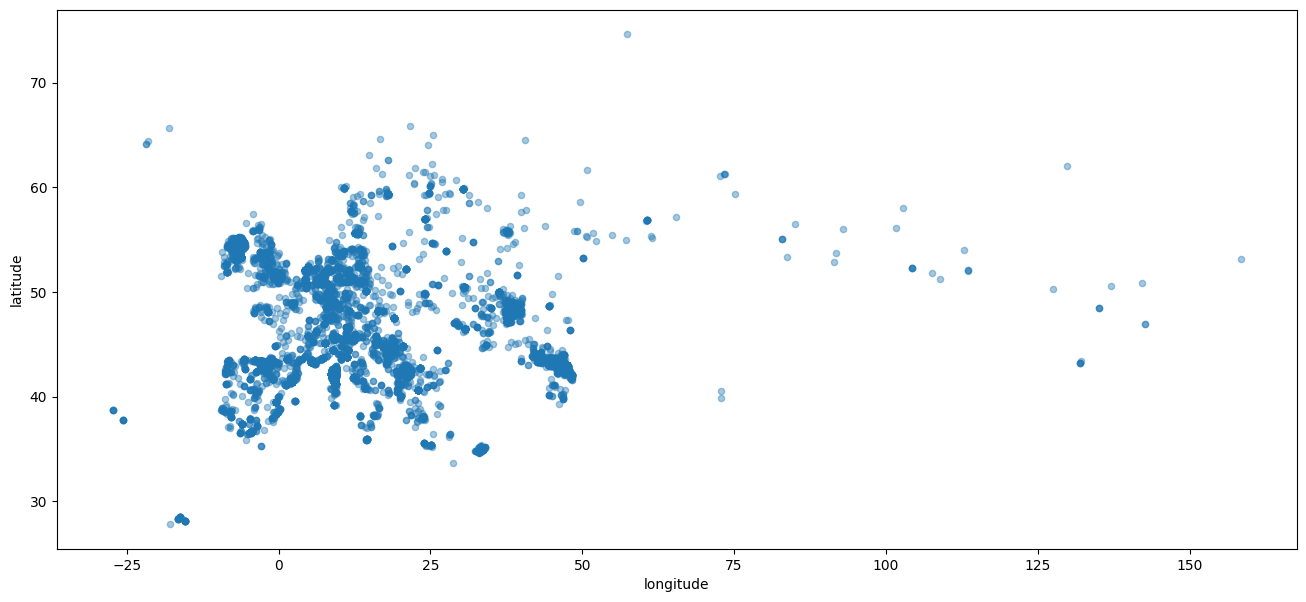

In [9]:
df_Ind.plot(kind= 'scatter', x='longitude', y='latitude', alpha=0.4, figsize=(16,7))
plt.show()

As for the number of casualties over the years the Balkans and Ukraine have been the most violent areas, closely followed by Northern Ireland.

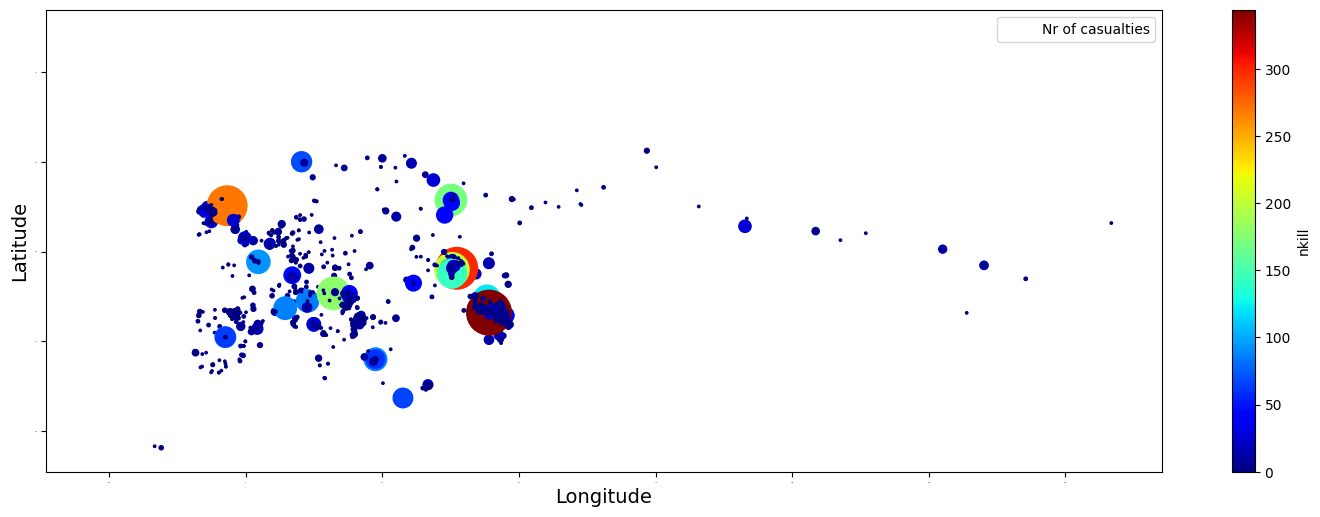

In [10]:
df_Ind.plot(kind= 'scatter', x='longitude', y='latitude', alpha=1.0,  figsize=(18,6),  
               s=df_Ind['nkill']*3, label= 'Nr of casualties', fontsize=1, c='nkill', cmap=plt.get_cmap("jet"), colorbar=True)
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)
plt.show()

There were still NaN's in some of the variables. We use the means of the available values to replace them :<br>
- **nkill** = 	0.686445<br>
- **latitude** = 47.004651
- **longitude** = 10.921231
- **natlty1** = 167.954530

In [11]:
df_Ind['nkill'].fillna(0.686445, inplace=True)
df_Ind['latitude'].fillna(47.004651, inplace=True)
df_Ind['longitude'].fillna(10.921231, inplace=True)
df_Ind['natlty1'].fillna(167.954530, inplace=True)

df_Ind.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21783 entries, 3 to 181660
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iyear            21783 non-null  int64  
 1   imonth           21783 non-null  int64  
 2   iday             21783 non-null  int64  
 3   extended         21783 non-null  int64  
 4   country          21783 non-null  int64  
 5   country_txt      21783 non-null  object 
 6   latitude         21783 non-null  float64
 7   longitude        21783 non-null  float64
 8   multiple         21783 non-null  float64
 9   success          21783 non-null  int64  
 10  suicide          21783 non-null  int64  
 11  attacktype1      21783 non-null  int64  
 12  attacktype1_txt  21783 non-null  object 
 13  targtype1        21783 non-null  int64  
 14  targtype1_txt    21783 non-null  object 
 15  natlty1          21783 non-null  float64
 16  natlty1_txt      21557 non-null  object 
 17  individual 

We now have a complete set of data. There are still 25 entries missing from nationalities (**natlty1_text**) but since it's a string variable and will not be used in calculations we decide to ignore this. <br><br>
Next, we start visualizing the data.  <br><br>
From the summary of the numerical attributes we can see that the mean for **success** is 0.856; i.e. the terror attacks in India have on average - unfortunately - been succesful in c. 17 cases out of 20. This high success rate is also visible in the charts.

In [12]:
terror_peryear = np.asarray(df_Ind.groupby('iyear').iyear.count())
successes_peryear = np.asarray(df_Ind.groupby('iyear').success.sum())

terror_years = np.arange(1970, 2016)

trace1 = go.Bar(x=terror_years, y=terror_peryear, name='Nr of terrorist attacks', 
                marker=dict(color='rgb(118,238,198)'), width=0.5)

trace2 = go.Scatter(x = terror_years, y = successes_peryear, name = 'Nr of succesful terrorist attacks',
         line = dict(color = ('rgb(205, 12, 24)'), width = 5,))

layout = go.Layout(title = 'Terrorist Attacks by Year in India ', legend=dict(orientation="h"),
         barmode = 'group')

figure = dict(data = [trace1,trace2], layout = layout)
#iplot(figure)
#Image("AttacksByYear.png")

In [13]:
import plotly.graph_objs as go

trace1 = go.Bar(
    y=['Ireland', 'West Germany (FRG)', 'Germany', 'Greece', 'Italy', 'Ukraine', 'Russia', 'France', 'Spain', 'United Kingdom'],
    x=[290, 541, 703, 1231, 1556, 1650, 2158, 2642, 3245, 5098],
    name='Nr of terrorist attacks per country',
    orientation='h', 
    marker=dict(color='rgba(255, 0, 0, 0.6)', line=dict(color='rgba(0, 255, 0, 0.6)', width=0.5))
)

trace2 = go.Bar(
    y=['Ireland', 'West Germany (FRG)', 'Germany', 'Greece', 'Italy', 'Ukraine', 'Russia', 'France', 'Spain', 'United Kingdom'],
    x=[135, 465, 633, 1092, 1384, 1479, 1780, 2441, 2814, 4107],
    name='Nr of successful terrorist attacks per country',
    orientation='h',
    marker=dict(color='rgba(128, 128, 0, 0.4)', line=dict(color='rgba(246, 78, 139, 0.2)', width=0.5))
)

data = [trace2, trace1]

layout = go.Layout(
    legend=dict(x=0.5, y=0.5),  # Placing legend in the middle
    title='Terrorist attacks in India <br>by Country  - TOP 10',
    barmode='group',
    bargap=0.1, 
    autosize=False,
    width=1000,
    height=1000
)

fig = go.Figure(data=data, layout=layout)
fig.show()


In [14]:
trace1 = go.Bar(
    y=['Andorra','Vatican City','Iceland','Montenegro','Romania','Slovenia','Lithuania','Czechoslovakia',
       'Serbia','Serbia-Montenegro','Belarus','Estonia','Latvia','Luxembourg','Finland','Norway','Slovak Republic',
       'Malta','Moldova','Czech Republic','Poland','East Germany (GDR)','Denmark','Hungary','Bulgaria','Croatia',
       'Soviet Union','Albania','Switzerland','Austria','Macedonia','Sweden','Netherlands','Cyprus','Portugal',
       'Belgium','Bosnia-Herzegovina','Kosovo','Yugoslavia'],
    x=[1,1,4,5,6,6,8,10,11,11,13,16,16,16,18,18,18,20,21,29,36,38,41,46,52,57,78,79,108,109,117,118,128,132,139,148,159,188,203],
    name='Nr of terrorist attacks per country',
    orientation = 'h',
    marker = dict(
        color = 'rgba(255,0,0, 0.6)',
        line = dict(
            color = 'rgba(246, 78, 139, 0.2)',
            width = 1)))

trace2 = go.Bar(
    y=['Andorra','Vatican City','Iceland','Montenegro','Romania','Slovenia','Lithuania','Czechoslovakia',
       'Serbia','Serbia-Montenegro','Belarus','Estonia','Latvia','Luxembourg','Finland','Norway','Slovak Republic',
       'Malta','Moldova','Czech Republic','Poland','East Germany (GDR)','Denmark','Hungary','Bulgaria','Croatia',
       'Soviet Union','Albania','Switzerland','Austria','Macedonia','Sweden','Netherlands','Cyprus','Portugal',
       'Belgium','Bosnia-Herzegovina','Kosovo','Yugoslavia'],
    x=[1,0,4,5,4,6,7,7,10,10,13,16,12,14,17,16,15,19,18,20,31,35,35,40,46,55,67,63,90,87,106,104,106,112,129,123,151,165,179],
    name='Nr of succesful terrorist attacks per country',
    orientation = 'h',
    marker = dict(
        color = 'rgba(128,128,0, 0.4)',
        line = dict(
            color = 'rgba(246, 78, 139, 0.2)',
            width = 0.5)))

data = [trace2, trace1]
layout = go.Layout(
    legend=dict(x=0.5, y=0.5), # placing legend in the middle
    title = 'Terrorist attacks in India <br>by Country outside the Top 10',
    barmode='group',
    bargap=0.1,
    #bargroupgap=0.1,
    autosize=False,
    width=900,
    height=1500,
)

fig = go.Figure(data=data, layout=layout)
#iplot(fig)
fig.show()

### Succesful attacks arranged by attack type
Next we look at the attacks by type seeing that Bombing/Explosion has by far been the dominating type. 

In [15]:
attacks_per_type = (df_Ind.groupby('attacktype1_txt').attacktype1_txt.count())
successes_per_type = (df_Ind.groupby('attacktype1_txt').success.sum())

trace2 = go.Bar(
    y=['Hijacking','Hostage Taking (Barricade Incident)','Unarmed Assault','Unknown','Hostage Taking (Kidnapping)','Facility/Infrastructure Attack','Armed Assault','Assassination','Bombing/Explosion'],
    x=[89,106,183,373,485,2752,2911,3295,11144],
    name='Nr of terrorist attacks',
    orientation = 'h',
    marker = dict(
        color = 'rgba(128,0,0, 0.8)',
        line = dict(
            color = 'rgba(246, 78, 139, 0.2)',
            width = 1)))

trace1 = go.Bar(
    y=['Hijacking','Hostage Taking (Barricade Incident)','Unarmed Assault','Unknown','Hostage Taking (Kidnapping)','Facility/Infrastructure Attack','Armed Assault','Assassination','Bombing/Explosion'],
    x=[76,105,149,333,457,2530,2637,2588,9393],
    name='Nr of succesful terrorist attacks',
    orientation = 'h',
    marker = dict(
        color = 'rgba(128,128,0, 0.4)',
        line = dict(
            color = 'rgba(246, 78, 139, 0.2)',
            width = 0.5)))

data = [trace1, trace2]
layout = go.Layout(
    legend=dict(x=0.5, y=0.5), # placing legend in the middle
    title = 'Terrorist attacks in India 1970-2016 <br>by Type',
    barmode='group',
    bargap=0.1,
    bargroupgap=0,
    autosize=False,
    width=1000,
    height=500,
)

fig = go.Figure(data=data, layout=layout)
fig.show()
#iplot(fig)


Next a look at the variables' correlations, numerically and graphically.

In [16]:
df_Ind.corr()

,iyear,imonth,iday,extended,country,latitude,longitude,multiple,success,suicide,attacktype1,targtype1,natlty1,individual,weaptype1,nkill
iyear,1.000000,0.001099,0.018084,0.040759,-0.118638,-0.024600,0.523868,0.145754,-0.104456,0.081896,0.148086,0.114062,0.066288,0.104055,0.041804,0.021602
imonth,0.001099,1.000000,0.015245,-0.009053,-0.003163,0.009278,0.021604,-0.035053,0.002001,0.019078,-0.017864,0.000924,0.015709,-0.001969,-0.011400,0.017249
iday,0.018084,0.015245,1.000000,0.005327,0.015456,0.022317,0.007788,-0.036299,-0.000120,-0.000137,-0.016991,0.010900,0.025253,0.012012,0.001656,-0.002976
extended,0.040759,-0.009053,0.005327,1.000000,-0.039755,-0.018814,0.094756,-0.028771,0.044350,-0.004209,0.132673,-0.003596,0.007318,-0.005645,0.191154,0.059146
country,-0.118638,-0.003163,0.015456,-0.039755,1.000000,0.638098,-0.406933,-0.105060,-0.073033,-0.026737,-0.138519,0.094929,0.524203,-0.018538,-0.115463,0.007699
latitude,-0.024600,0.009278,0.022317,-0.018814,0.638098,1.000000,-0.322787,-0.103413,-0.080015,-0.007310,-0.008888,0.145469,0.290816,0.034393,-0.006459,0.015374
longitude,0.523868,0.021604,0.007788,0.094756,-0.406933,-0.322787,1.000000,0.047925,0.039818,0.101985,0.035479,-0.012823,-0.075356,-0.012447,0.000042,0.068103
multiple,0.145754,-0.035053,-0.036299,-0.028771,-0.105060,-0.103413,0.047925,1.000000,0.029981,0.032392,0.107670,-0.022492,-0.067989,-0.012700,0.060872,-0.002782
success,-0.104456,0.002001,-0.000120,0.044350,-0.073033,-0.080015,0.039818,0.029981,1.000000,0.012219,0.087720,-0.063507,-0.033917,-0.010617,0.039098,0.044604
suicide,0.081896,0.019078,-0.000137,-0.004209,-0.026737,-0.007310,0.101985,0.032392,0.012219,1.000000,-0.012873,0.008384,-0.001838,0.049633,-0.016064,0.163292


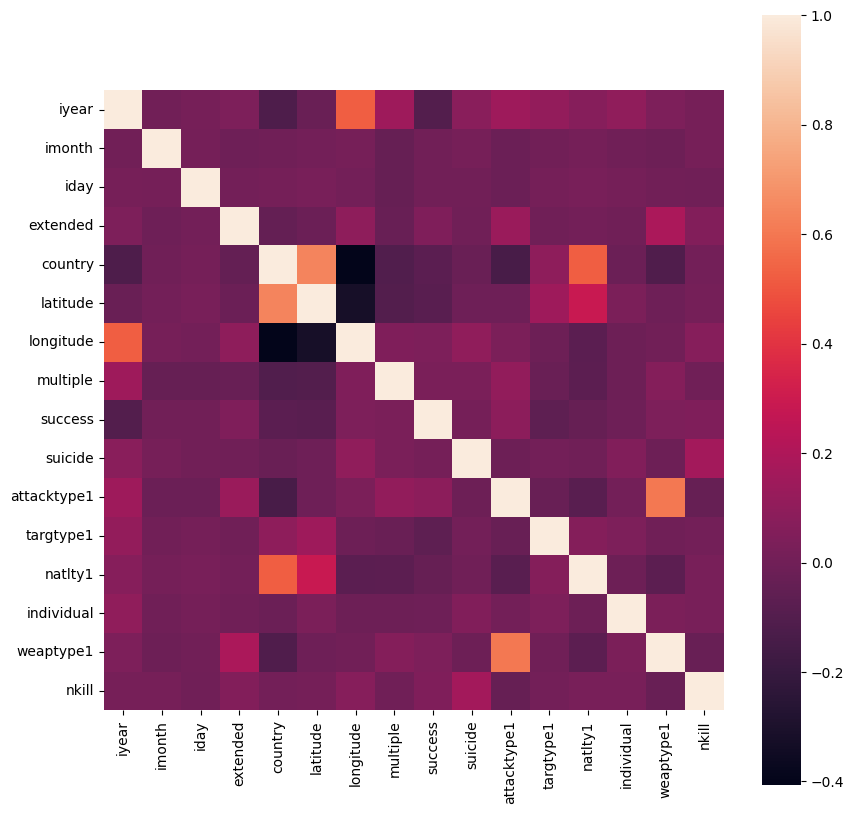

In [17]:
corrmat = df_Ind.corr()
f, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(corrmat, vmax=1, square=True);
plt.show()

There are some obvious higher correlations, like between **nationality** & **country** and **attacktype** & **weapontype**. Otherwise variables are fairly non-correlated, which looks good for the model; we don't have closely related variables basically just capturing the same thing.<br><br>
Going forward, we will further drop string objects from the data with the extension '_txt'. These variables will still be found as *numerical* values in the data, though. 

### Train Test split 
Now we need to split our data to a train set (80%) and test set (20%).  The variable we're trying to predict is **success**; what determines whether a terrorist attack will be succesful or not. <br>
The **random_state** -variable of the split is set to a fixed number, here the somewhat arbitrary '42', thereby keeping the random number generator constant. This way we will always be getting the same split and avoid the risk of introducing sampling bias.

In [21]:
#from sklearn.model_selection import train_test_split
X = df_Ind.drop(['iyear', 'success','country', 'country_txt', 'attacktype1_txt','targtype1_txt','natlty1', 'natlty1_txt', 'weaptype1_txt'], axis=1)
y = df_Ind['success']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

Next, we need to separate the *features* from the *target* that we're trying to build a Decision Tree for (and later a Random Forest).<br>
We skip variable **'iyear'**, since past years cannot reoccur and have therefore no impact on the prediction. Also, we skip variable **'country'**, since it must fit together with the variables **'longitude'** and **'latitude'** anyway and does not bring additional value on its own.


In [22]:
features = [ 'imonth', 'iday', 'extended',  'latitude', 'longitude', 'multiple','suicide','attacktype1',
            'targtype1', 'individual', 'weaptype1', 'nkill']

### Performance Measures for Prediction and Evaluation
We use a Confusion Matrix first on a Decision Tree then on a Random Forest to evaluate the accuracy of each method.<br>

|       |                 |
|-----------------------|:--------------------:|
| True Negatives (TN)  |  False Positives (FP) |
| False Negatives (FN)  |  True Positives (TP) |
<br>
In a perfect model both **False Positives** and **False Negatives** in the matrix would be zero!<br><br>
In our model for predicting the succesfulness of terrorist attacks the interpretation is as follows:<br><br>
- TN = The model predicts correctly a non-succesful attack
- TP = The model predicts correctly a succesful attack
- FN = The model predicts a succesful attack wrongfully to be non-succesful
- FP = The model predicts a non-succesful attack wrongfully to be succesful<br><br>

The **Precision**(=accuracy of the positive predictions), **Recall**(=ratio of positive instances correctly detected by the classifier) and **f1-score** may be more concise metrics, however.

- **Precision** for 'success' = TP/(TP+FP) <br>
- **Precision** for *not* 'success' = TN/(TN+FN) <br><br>
- **Recall** for 'success' = TP/(TP+FN)  <br>
- **Recall** for *not* 'success' = TN/(TN+FP)  <br><br>
- The **f1-score** is the harmonic mean of Precision and Recall.


### Decision Tree - with max node depth of 3

Now we will construct the actual Decision Tree. Just to make the first try more visual we stick to a max depth of 3 for the decision nodes.

In [40]:
y = df_Ind['success'] #this is what we're trying to predict!
X = df_Ind[features]
dtc = tree.DecisionTreeClassifier(max_depth=3) 
dtc = dtc.fit(X_train,y_train)
#Two lines of code to create the classifier!!

And a look at the results:

In [42]:
dtc_pred = dtc.predict(X_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,dtc_pred))

              precision    recall  f1-score   support

           0       0.85      0.21      0.34       607
           1       0.89      0.99      0.94      3750

    accuracy                           0.88      4357
   macro avg       0.87      0.60      0.64      4357
weighted avg       0.88      0.88      0.85      4357



In [43]:
print(confusion_matrix(y_test,dtc_pred))

[[ 128  479]
 [  23 3727]]


###  Decision Tree - no max node depth

In [44]:
y = df_Ind['success'] 
X = df_Ind[features]
dtc = tree.DecisionTreeClassifier() 
dtc = dtc.fit(X_train,y_train)

The graphical Decision Tree would be too complex to be presented visually so we go with numerical results only.

In [45]:
dtc_pred = dtc.predict(X_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,dtc_pred))

              precision    recall  f1-score   support

           0       0.43      0.49      0.46       607
           1       0.92      0.89      0.91      3750

    accuracy                           0.84      4357
   macro avg       0.67      0.69      0.68      4357
weighted avg       0.85      0.84      0.84      4357



In [46]:
print(confusion_matrix(y_test,dtc_pred))

[[ 299  308]
 [ 396 3354]]


**True Negatives** have more than doubled, **False Positives** have decreased by a third and **False Negatives** are much higher.<br>
Since Decision Trees can suffer from overfitting, we will continue with Random Forests to see if we can improve the model.

### Random Forest
After trying with various *n_estimators*, i.e. "number of trees in the forest", with 10 being the default, the optimal **confusion_matrix** was received with (n_estimators=400). Increasing the number to up to 1000 did not improve the outcome, but slightly to the contrary. 

In [47]:
rfc = RandomForestClassifier(n_estimators=400) 
rfc = rfc.fit(X_train, y_train)
rfc_pred = rfc.predict(X_test)

In [20]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# Train the model
rfc = RandomForestClassifier(n_estimators=400)
rfc.fit(X_train, y_train)

# Save the trained model to a file
joblib.dump(rfc, 'random_forest_model.pkl')

# Later, when you want to use the model for prediction
# Load the model from the file
rfc_loaded = joblib.load('random_forest_model.pkl')

# # Use the loaded model for prediction
# rfc_pred = rfc_loaded.predict(X_test)

In [23]:
print(classification_report(y_test,rfc_pred))

NameError: name 'classification_report' is not defined

In [50]:
print(confusion_matrix(y_test,rfc_pred))

[[ 253  354]
 [  99 3651]]


Overall, comparing the Confusion Matrix of the latter Decision Tree with the Random Forest, the difference is not very striking, except for the clear reduction in False Negatives. The Classification Report does show a clearer improvement, though. We decide to go with the Random Forest model!

### Checking for feature importance
We can also check for the relative importance of each attribute for making accurate predictions. With this information, we could drop some of the less useful features, should we decide to fine-tune the model further.

In [51]:
for name, score in zip(X_train[features], rfc.feature_importances_):
    print(name, score)

imonth 0.11769888317507066
iday 0.17464778057458422
extended 0.0020172434139460967
latitude 0.1650770465689595
longitude 0.1686567175400738
multiple 0.012452066795298995
suicide 0.0012472911319041835
attacktype1 0.10713094833652266
targtype1 0.12017930677702202
individual 0.002485251410325737
weaptype1 0.04043106946750992
nkill 0.08797639480878233


We sort the results and take a look at them graphically:

In [53]:
data = go.Bar(
    y=['suicide', 'individual', 'extended', 'multiple', 'weaptype1', 'nkill', 'attacktype1','targtype1', 
       'imonth',  'iday', 'latitude',  'longitude'],
    x=[0.001182,0.002047,0.002392,0.011422,0.041777,0.085776,0.107362,0.109867,0.113829,0.167432,0.173583,0.18333],   
    orientation = 'h',
    marker = dict(color = 'rgba(255,0,0, 0.6)', line = dict(width = 0.5)))

data = [data]
layout = go.Layout(title = 'Relative Importance of the Features in the Random Forest',
    barmode='group', bargap=0.1, width=800,height=500,)

fig = go.Figure(data=data, layout=layout)
#iplot(fig)
fig.show()


In [24]:
import joblib

# Load the trained model from the file
rfc_loaded = joblib.load('random_forest_model.pkl')

# Define the features for prediction
month = 12           # in which month would the attack take place
day = 23             # on which day of the month would the attack take place
extended = 1         # 1=yes, 0=no
latitude = 48.8566
longitude = 2.3522
multiple = 0         # attack is part of a multiple incident (1), or not (0)
suicide = 0          # suicide attack (1) or not (0)
attackType = 0       # 9 categories
targetType = 0       # 22 categories
individual = 0       # known group/organization (1) or not (0)
weaponType = 0       # 13 categories
nkill = 0            # number of total casualties from the attack

# Make prediction using the loaded model
outcome = rfc_loaded.predict([[month, day, extended, latitude, longitude, multiple, suicide, attackType, targetType, individual, weaponType, nkill]])

if outcome == 1:
    print("The attack based on these features would be successful.")
elif outcome == 0:
    print("The attack based on these features would NOT be successful.")


The attack based on these features would be successful.


c:\users\lenovo\appdata\local\programs\python\python37\lib\site-packages\sklearn\base.py:451: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names



In [20]:
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.metrics import classification_report
import joblib

# Define features excluding 'extended' and 'suicide'
features = ['imonth', 'iday', 'latitude', 'longitude', 'multiple', 'attacktype1',
            'targtype1', 'individual', 'weaptype1', 'nkill']

# Split data into features (X) and target variable (y)
X = df_Ind[features]
y = df_Ind['success']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Train a decision tree classifier
dtc = tree.DecisionTreeClassifier(max_depth=3)
dtc = dtc.fit(X_train, y_train)

# Make predictions on the test set
dtc_pred = dtc.predict(X_test)

# Print classification report
print(classification_report(y_test, dtc_pred))

import joblib

# Save the trained decision tree classifier model
joblib.dump(dtc, 'decision_tree_model.pkl')

# Load the trained decision tree classifier model
dtc_loaded = joblib.load('decision_tree_model.pkl')

# Define the features for prediction (excluding 'extended' and 'suicide')
month = 12           # in which month would the attack take place
day = 23             # on which day of the month would the attack take place
latitude = 48.8566
longitude = 2.3522
multiple = 0         # attack is part of a multiple incident (1), or not (0)
attackType = 5       # 9 categories
targetType = 16       # 22 categories
individual = 1       # known group/organization (1) or not (0)
weaponType = 5       # 13 categories
nkill = 0            # number of total casualties from the attack

# Make prediction using the loaded model
outcome = dtc_loaded.predict([[month, day, latitude, longitude, multiple, attackType, targetType, individual, weaponType, nkill]])

# Print the outcome
if outcome == 1:
    print("The attack based on these features would be successful.")
elif outcome == 0:
    print("The attack based on these features would NOT be successful.")


              precision    recall  f1-score   support

           0       0.85      0.21      0.34       607
           1       0.89      0.99      0.94      3750

    accuracy                           0.88      4357
   macro avg       0.87      0.60      0.64      4357
weighted avg       0.88      0.88      0.85      4357

The attack based on these features would be successful.


c:\users\lenovo\appdata\local\programs\python\python37\lib\site-packages\sklearn\base.py:451: UserWarning:

X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names



Looks like dropping the features **extended**, **individual** and **suicide** might be considered. 

### Checking the outcome with inserted data
Now we finally have a model using which we can actually predict whether an attack is expected to succeed or fail.<br>
By typing in the twelve variables the model gives the predicted outcome.